# FinTrust Digital Bank – Week 3 Advanced Python Analysis

## Objective

This notebook extends the Week 2 exploratory data analysis by performing deeper comparative, trend, segmentation and validation analysis.

The objective is to move beyond descriptive summaries and investigate relationships and patterns that can support more decision-oriented business intelligence.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Customer and Transaction Datasets

In [3]:
customers = pd.read_csv("../week1/FinTrust_Customer_Clean_Data.csv")
transactions = pd.read_csv("../week1/FinTrust_Transaction_Clean_Data.csv")

### Analysis 1 — Monthly Transaction Trend

#### Convert transaction date:

In [4]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"]
)

#### Create the monthly summary

In [5]:
monthly_trend = (
    transactions
    .set_index("Transaction_Date")
    .resample("ME")
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum")
    )
    .reset_index()
)

monthly_trend

,Transaction_Date,Total_Transactions,Total_Transaction_Value
0,2026-01-31,4133,1.884894e+08
1,2026-02-28,3734,1.757869e+08
2,2026-03-31,4133,1.962010e+08


### Interpretation

#### What does the analysis show?

Transaction activity declined in February 2026 and recovered in March.

January recorded 4,133 transactions with a total transaction value of approximately NGN 188.49 million. February declined to 3,734 transactions and approximately NGN 175.79 million in transaction value.

In March, transaction volume recovered to 4,133 transactions, while total transaction value increased further to approximately NGN 196.20 million.

#### Why is it important?

Monthly trend analysis helps FinTrust identify periods of declining or improving transaction activity rather than relying only on overall totals.

#### Business Insight

February experienced a temporary decline in both transaction volume and value, followed by a strong recovery in March. Although March recorded the same number of transactions as January, it generated a higher total transaction value, indicating stronger transaction value performance during the month.

#### Validation

The Python results support the Week 3 SQL analysis, which also identified a decline in February followed by a recovery in March.

## Analysis 2 – Transaction Failure Rate by Channel and Transaction Type

### Business Question
Which banking channel and transaction-type combinations have the highest transaction failure rates?

In [6]:
# Create a failed-transaction indicator
transactions["Failed"] = (
    transactions["Transaction_Status"] == "Failed"
).astype(int)

# Calculate failure rate by channel and transaction type
failure_analysis = (
    transactions
    .groupby(["Channel", "Transaction_Type"])
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Failed_Transactions=("Failed", "sum")
    )
    .reset_index()
)

# Calculate failure rate percentage
failure_analysis["Failure_Rate_Percent"] = (
    failure_analysis["Failed_Transactions"]
    / failure_analysis["Total_Transactions"]
    * 100
).round(2)

# Keep combinations with at least 20 transactions
failure_analysis = failure_analysis[
    failure_analysis["Total_Transactions"] >= 20
]

# Show combinations with highest failure rates
failure_analysis.sort_values(
    "Failure_Rate_Percent",
    ascending=False
).head(10)

,Channel,Transaction_Type,Total_Transactions,Failed_Transactions,Failure_Rate_Percent
13,POS,Bill Payment,291,21,7.22
23,USSD,Transfer,250,18,7.20
16,POS,Deposit,268,17,6.34
25,Web,Bill Payment,223,14,6.28
24,Web,Airtime/Data,176,11,6.25
8,Mobile App,Card Purchase,1263,78,6.18
11,Mobile App,Transfer,1526,93,6.09
21,USSD,Cash Withdrawal,100,6,6.00
9,Mobile App,Cash Withdrawal,626,36,5.75
7,Mobile App,Bill Payment,643,37,5.75


### Visualization

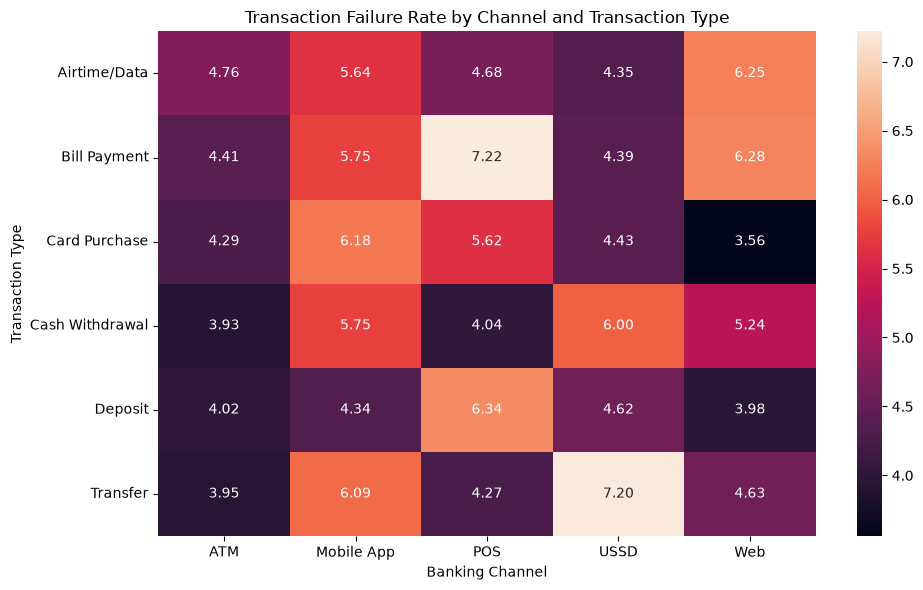

In [7]:
# Prepare data for the heatmap
failure_pivot = failure_analysis.pivot(
    index="Transaction_Type",
    columns="Channel",
    values="Failure_Rate_Percent"
)

# Create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    failure_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Transaction Failure Rate by Channel and Transaction Type")
plt.xlabel("Banking Channel")
plt.ylabel("Transaction Type")

plt.tight_layout()
plt.show()

### Interpretation

#### What does the visual show?

The heatmap compares transaction failure rates across different combinations of banking channels and transaction types.

POS Bill Payments recorded the highest failure rate at 7.22%, followed closely by USSD Transfers at 7.20%. POS Deposits, Web Bill Payments and Web Airtime/Data transactions also showed relatively higher failure rates.

The lowest failure rate was observed for Web Card Purchases at 3.56%.

#### Why is it important?

Looking only at the overall failure rate can hide differences between individual banking channels and transaction types. Analysing both dimensions together helps identify specific combinations where transaction performance may require closer attention.

#### Business Insight

Transaction failure rates are not evenly distributed across FinTrust's channels and transaction types. POS Bill Payments and USSD Transfers show the highest failure rates, suggesting that these combinations may warrant further operational investigation.

However, failure rate should also be considered alongside transaction volume because a high-volume combination may generate more failed transactions even when its percentage failure rate is lower.

#### Validation

The Python results support the Week 3 SQL analysis, which also identified POS Bill Payments and USSD Transfers as the combinations with the highest failure rates.

## Analysis 3 — Transaction Value by Customer Segment

In [8]:
fintrust = transactions.merge(
    customers,
    on="Customer_ID",
    how="left"
)

In [9]:
fintrust.shape

(12000, 25)

## Visualization

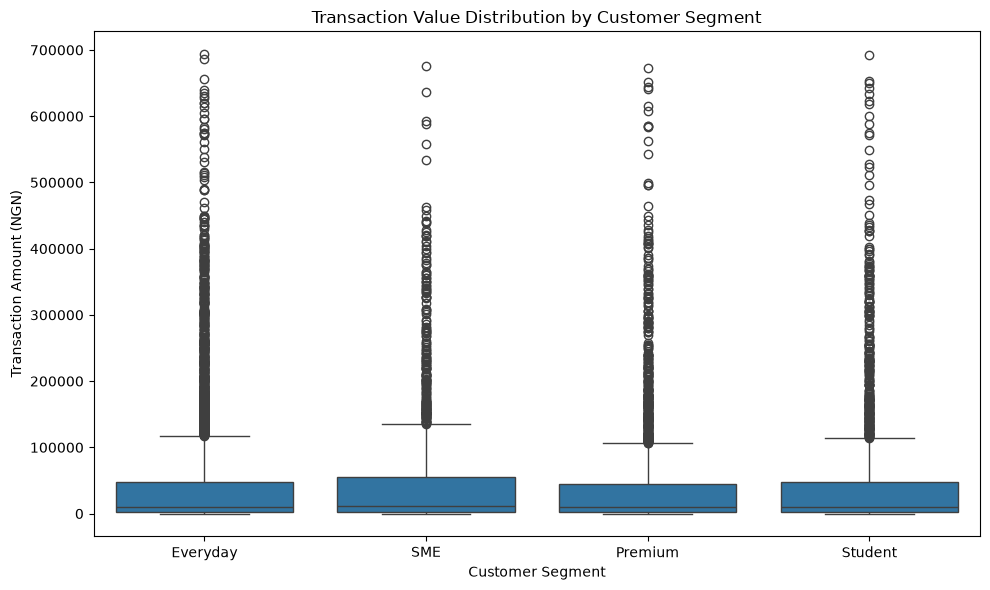

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=fintrust,
    x="Customer_Segment",
    y="Amount_NGN"
)

plt.title("Transaction Value Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Transaction Amount (NGN)")

plt.tight_layout()
plt.show()

### Interpretation

#### What does the visual show?

Transaction values are strongly right-skewed across all customer segments. Most transactions are concentrated at lower transaction amounts, while each segment also contains a substantial number of high-value transactions.

The overall transaction-value distributions are broadly similar across Everyday, SME, Premium and Student customers, although there are some differences in the spread of transaction amounts.

#### Why is it important?

Comparing transaction distributions provides more information than comparing total transaction value alone. A segment may generate a high overall value because it has more customers or transactions, rather than because its typical transaction is larger.

#### Business Insight

FinTrust should avoid evaluating customer segments using total transaction value alone. The wide variation within each segment indicates that customer-level behaviour and transaction-size patterns should also be considered when assessing segment value.

## Analysis 4 – Risk Review Rate by Transaction Amount

### Business Question
Does the risk-review rate increase as transaction value increases?

In [11]:
# Create transaction amount bands
transactions["Amount_Band"] = pd.cut(
    transactions["Amount_NGN"],
    bins=[0, 10000, 50000, 100000, 200000, float("inf")],
    labels=[
        "Below 10K",
        "10K - 49,999",
        "50K - 99,999",
        "100K - 199,999",
        "200K and Above"
    ],
    right=False
)

# Calculate risk-review rate
risk_by_amount = (
    transactions
    .groupby("Amount_Band", observed=False)
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Risk_Review_Transactions=(
            "Risk_Review_Flag",
            lambda x: (x == "Yes").sum()
        )
    )
    .reset_index()
)

risk_by_amount["Risk_Review_Rate_Percent"] = (
    risk_by_amount["Risk_Review_Transactions"]
    / risk_by_amount["Total_Transactions"]
    * 100
).round(2)

risk_by_amount

,Amount_Band,Total_Transactions,Risk_Review_Transactions,Risk_Review_Rate_Percent
0,Below 10K,5947,1050,17.66
1,"10K - 49,999",3110,554,17.81
2,"50K - 99,999",1214,230,18.95
3,"100K - 199,999",994,220,22.13
4,200K and Above,735,298,40.54


### Interpretation

#### What does the analysis show?

The risk-review rate increases as transaction value rises. Transactions below NGN 100,000 have risk-review rates of approximately 18%, while the rate rises to 22.13% for transactions between NGN 100,000 and NGN 199,999.

The strongest increase occurs among transactions of NGN 200,000 and above, where the risk-review rate reaches 40.54%.

#### Why is it important?

This shows that risk-review activity is not evenly distributed across transaction values. Higher-value transactions are much more likely to be selected for additional review.

#### Business Insight

FinTrust's risk-review pattern is strongly associated with transaction value, particularly for transactions of NGN 200,000 and above. This suggests that high-value transactions receive greater review attention.

However, the Risk_Review_Flag represents a synthetic review indicator and should not be interpreted as confirmed fraud.

#### Validation

The Python analysis fully supports the Week 3 SQL finding. Both methods produced the same transaction counts and risk-review rates across the amount bands, including a 40.54% review rate for transactions of NGN 200,000 and above.

## Analysis 5 – Digital Engagement and Customer Transaction Behaviour

### Business Question
Do customers with higher digital engagement scores transact more frequently and generate more transaction value?

In [12]:
# Create customer-level transaction summary
customer_activity = (
    fintrust
    .groupby(["Customer_ID", "Digital_Engagement_Score"])
    .agg(
        Total_Transactions=("Transaction_ID", "count"),
        Total_Transaction_Value=("Amount_NGN", "sum")
    )
    .reset_index()
)

# Create engagement categories
customer_activity["Engagement_Level"] = pd.cut(
    customer_activity["Digital_Engagement_Score"],
    bins=[0, 40, 70, float("inf")],
    labels=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ],
    right=False
)

# Summarise behaviour by engagement level
engagement_summary = (
    customer_activity
    .groupby("Engagement_Level", observed=False)
    .agg(
        Total_Customers=("Customer_ID", "count"),
        Average_Transactions_Per_Customer=("Total_Transactions", "mean"),
        Average_Transaction_Value_Per_Customer=("Total_Transaction_Value", "mean")
    )
    .reset_index()
)

# Round the results
engagement_summary["Average_Transactions_Per_Customer"] = (
    engagement_summary["Average_Transactions_Per_Customer"].round(2)
)

engagement_summary["Average_Transaction_Value_Per_Customer"] = (
    engagement_summary["Average_Transaction_Value_Per_Customer"].round(2)
)

engagement_summary

,Engagement_Level,Total_Customers,Average_Transactions_Per_Customer,Average_Transaction_Value_Per_Customer
0,Low Engagement,96,7.97,359967.31
1,Medium Engagement,721,7.89,369721.08
2,High Engagement,683,8.12,379724.15


## Visualization

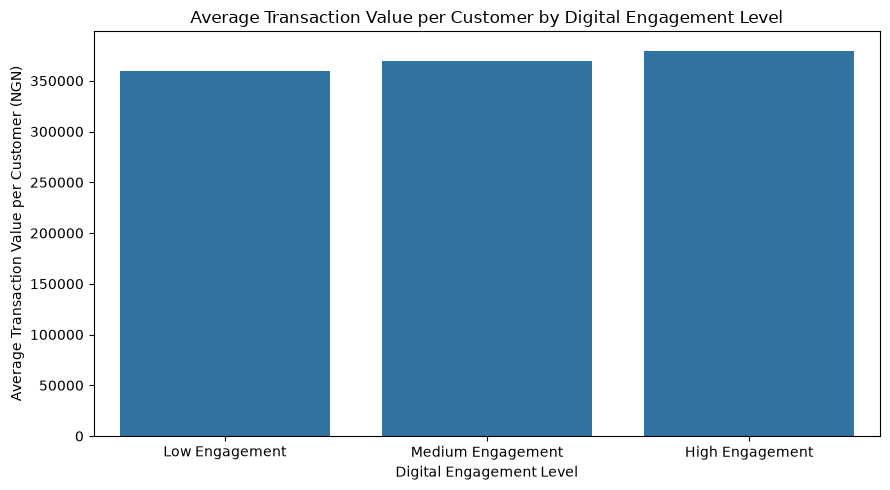

In [13]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=engagement_summary,
    x="Engagement_Level",
    y="Average_Transaction_Value_Per_Customer"
)

plt.title("Average Transaction Value per Customer by Digital Engagement Level")
plt.xlabel("Digital Engagement Level")
plt.ylabel("Average Transaction Value per Customer (NGN)")

plt.tight_layout()
plt.show()

### Interpretation

#### What does the analysis show?

Customers with higher digital engagement generally generate greater transaction value per customer.

Low-engagement customers generated an average transaction value of approximately NGN 359,967 per customer, compared with NGN 369,721 for medium-engagement customers and NGN 379,724 for high-engagement customers.

High-engagement customers also recorded the highest average transaction frequency at 8.12 transactions per customer, compared with 7.97 for low-engagement customers and 7.89 for medium-engagement customers.

#### Why is it important?

Digital engagement may help FinTrust understand differences in customer activity and value. Customers who interact more strongly with digital banking services also show somewhat higher transaction activity and transaction value.

#### Business Insight

Higher digital engagement is associated with slightly greater transaction frequency and higher transaction value per customer. The differences are moderate, so digital engagement should be considered alongside other customer characteristics when evaluating customer behaviour.

#### Validation

The Python results support the Week 3 SQL analysis. Both approaches produced the same customer counts, average transaction frequencies and average transaction values across the three engagement levels.